In [13]:
!pip install tensorflow matplotlib


In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt


In [15]:
#load mnist data set
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training Images Shape:", x_train.shape)
print("Testing Images Shape:", x_test.shape)

Training Images Shape: (60000, 28, 28)
Testing Images Shape: (10000, 28, 28)


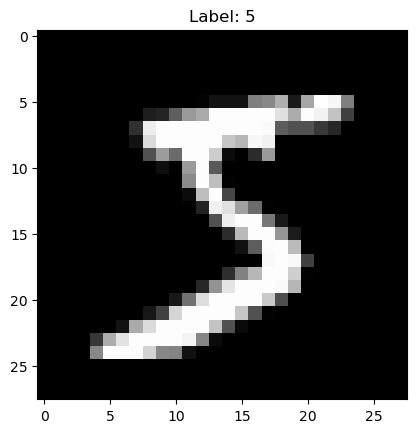

In [16]:
#display a simple image
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [17]:
#normalize a data 
x_train = x_train / 255.0
x_test = x_test / 255.0

In [18]:
# build feed forward neural network
model = Sequential([
    
    Flatten(input_shape=(28, 28)),
    
    Dense(128, activation='relu'),
    
    Dense(64, activation='relu'),
    
    Dense(10, activation='softmax')
])

In [19]:
#compile the model 
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
#train the model 
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9248 - loss: 0.2570 - val_accuracy: 0.9663 - val_loss: 0.1088
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9664 - loss: 0.1081 - val_accuracy: 0.9692 - val_loss: 0.0937
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9767 - loss: 0.0736 - val_accuracy: 0.9747 - val_loss: 0.0895
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9825 - loss: 0.0556 - val_accuracy: 0.9760 - val_loss: 0.0836
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9855 - loss: 0.0444 - val_accuracy: 0.9770 - val_loss: 0.0932
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9883 - loss: 0.0369 - val_accuracy: 0.9772 - val_loss: 0.0860
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9904 - loss: 0.0295 - val_accuracy: 0.9760 - val_loss: 0.0963
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9919 - 

In [21]:
#evaluate model 
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9763 - loss: 0.0894
Test Accuracy: 0.9763000011444092


In [22]:
#make predictions 
predictions = model.predict(x_test)

predicted_label = predictions[0].argmax()

print("Predicted:", predicted_label)
print("Actual:", y_test[0])


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Predicted: 7
Actual: 7


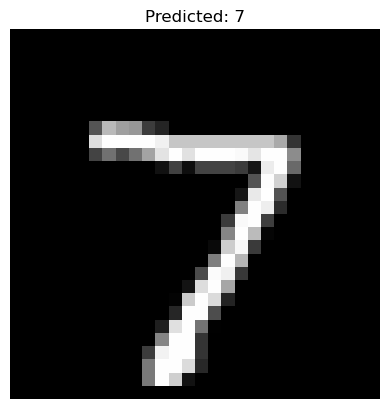

In [23]:
#visualize predictions 
plt.imshow(x_test[0], cmap='gray')
plt.title(f"Predicted: {predicted_label}")
plt.axis('off')
plt.show()

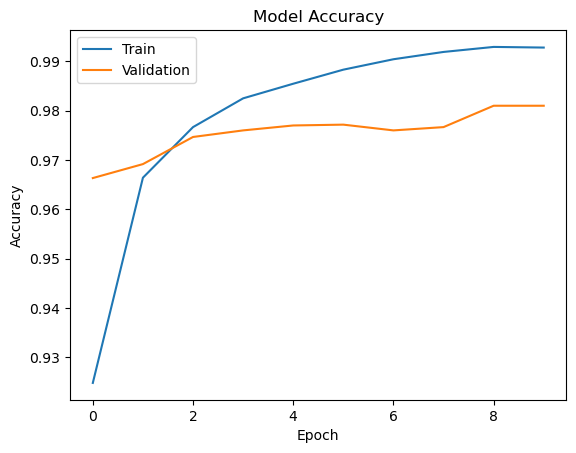

In [24]:
#plot accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])
plt.show()